# Comparación de modelos individuales PINN–XGBoost — Interpolación — R1

**Propósito:** comparar modelos individuales, sin ensambles, mediante precisión exterior,
almacenamiento desplegable y latencia de inferencia CPU1 batch=1.

**Alcance:** contaminantes CO y NOx en el protocolo interpolativo.

**Entradas principales:** resultados finales por semilla, paquetes de modelo y benchmark
CPU1 común generado por las campañas XGBoost R2.

**Salidas principales:** base consolidada, fronteras de Pareto, figura 3D, proyecciones 2D
y resumen por configuración.

**Entorno:** ejecución local o Google Colab con la estructura canónica del proyecto.

**Estado:** análisis comparativo reproducible. No modifica modelos ni reabre la selección.

> La latencia empleada es la métrica primaria del contrato común:
> **end-to-end p95 CPU1, batch=1**, medida sobre cada modelo individual. El tiempo de
> entrenamiento no participa en esta comparación.

## Mapa del notebook

| Sección | Finalidad |
|---|---|
| SEC-00 | propósito, alcance y reglas de comparación |
| SEC-01 | entorno y dependencias |
| SEC-02 | rutas y fuentes de verdad |
| SEC-03 | carga y validación de artefactos |
| SEC-04 | consolidación de modelos individuales |
| SEC-05 | cálculo de fronteras no dominadas |
| SEC-06 | superficie 3D y visualizaciones 2D |
| SEC-07 | persistencia y resumen |

## SEC-01 — Entorno y dependencias

### C-01.01 — Importación y registro del entorno

**Objetivo:** cargar únicamente dependencias de análisis y visualización.
**Salidas:** versiones de Python, pandas, NumPy y Matplotlib.

In [1]:
# [C-01.01] Importación y registro del entorno
from __future__ import annotations

import json
import platform
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter, ScalarFormatter

print(f"Python     : {platform.python_version()}")
print(f"NumPy      : {np.__version__}")
print(f"pandas     : {pd.__version__}")
print(f"Matplotlib : {matplotlib.__version__}")

Python     : 3.12.13
NumPy      : 2.1.3
pandas     : 2.2.3
Matplotlib : 3.11.1


## SEC-02 — Rutas y fuentes de verdad

### C-02.01 — Resolución de la raíz del proyecto

**Objetivo:** admitir ejecución local y en Google Colab sin rutas ocultas.
**Control:** todas las entradas deben existir antes de iniciar el análisis.

In [2]:
# [C-02.01] Resolución de rutas
LOCAL_ROOT = Path(r"C:\ChatGPT-Work\Walk_Forward R8")
COLAB_ROOT = Path("/content/drive/MyDrive/Turbine_Emissions_PINN")

if COLAB_ROOT.exists():
    PROJECT_ROOT = COLAB_ROOT
elif LOCAL_ROOT.exists():
    PROJECT_ROOT = LOCAL_ROOT
else:
    candidate_root = Path.cwd().resolve()
    PROJECT_ROOT = candidate_root.parent if candidate_root.name == "notebooks" else candidate_root

OUTPUT_ROOT = (
    PROJECT_ROOT
    / "models"
    / "interp"
    / "work_pinn_xgboost_pareto_latency_r1"
)
TABLES_DIR = OUTPUT_ROOT / "tables"
FIGURES_DIR = OUTPUT_ROOT / "figures"
REPORTS_DIR = OUTPUT_ROOT / "reports"

for output_directory in (TABLES_DIR, FIGURES_DIR, REPORTS_DIR):
    output_directory.mkdir(parents=True, exist_ok=True)

TASKS = {
    "CO": {
        "xgb_final": PROJECT_ROOT / "models/interp/work_xgboost_co_interp_final_r2f_budget_matched",
        "pinn_final": PROJECT_ROOT / "models/interp/work_pinn_co_interp_final_r4_std",
        "pinn_model_glob": "models/PINN_CO_INTERP_seed*.pt",
    },
    "NOx": {
        "xgb_final": PROJECT_ROOT / "models/interp/work_xgboost_nox_interp_final_r2f_budget_matched",
        "pinn_final": PROJECT_ROOT / "models/interp/work_pinn_nox_interp_final_r5_std",
        "pinn_model_glob": "models/PINN_NOX_INTERP_seed*.pt",
    },
}

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"OUTPUT_ROOT : {OUTPUT_ROOT}")

PROJECT_ROOT: C:\ChatGPT-Work\Walk_Forward R8
OUTPUT_ROOT : C:\ChatGPT-Work\Walk_Forward R8\models\interp\work_pinn_xgboost_pareto_latency_r1


## SEC-03 — Carga y validación de artefactos

### C-03.01 — Contrato mínimo de entradas

**Objetivo:** comprobar que cada modelo tenga R² TEST, tamaño serializado y latencia
end-to-end p95 obtenida con el benchmark CPU1 común.

**Acción ante fallo:** detener la ejecución; no se permiten sustituciones por tiempo de
entrenamiento ni por latencias estimadas.

In [3]:
# [C-03.01] Contrato mínimo de entradas
REQUIRED_XGB_TABLES = [
    "common_cpu1_benchmark_single_summary.csv",
    "test_metrics_individual_replicates.csv",
    "training_summary_by_candidate_seed.csv",
]
REQUIRED_PINN_TABLE = "test_metrics_by_seed.csv"

required_paths = []
for task in TASKS.values():
    required_paths.extend(
        task["xgb_final"] / "tables" / filename
        for filename in REQUIRED_XGB_TABLES
    )
    required_paths.append(task["pinn_final"] / "tables" / REQUIRED_PINN_TABLE)

missing_paths = [path for path in required_paths if not path.exists()]
if missing_paths:
    formatted = "\n".join(f"- {path}" for path in missing_paths)
    raise FileNotFoundError(f"Faltan entradas obligatorias:\n{formatted}")

print(f"CHK-01 OK: {len(required_paths)} entradas tabulares verificadas.")

CHK-01 OK: 8 entradas tabulares verificadas.


## SEC-04 — Consolidación de modelos individuales

#### ALG-01 — Unión por contaminante, familia, configuración y semilla

**Lógica humana:**
1. leer las latencias CPU1 medidas para modelos individuales;
2. unir cada XGBoost con su R² TEST y su paquete UBJ más metadatos;
3. unir cada PINN con su R² TEST y el tamaño real de su checkpoint `.pt`;
4. conservar solo registros con las tres magnitudes observadas;
5. verificar que no aparezcan filas de ensamble.

### C-04.01 — Construcción de la base comparable

In [4]:
# [C-04.01] Construcción de la base comparable
def parse_seed_from_path(model_path: Path) -> int:
    # Extrae la semilla desde un nombre terminado en ``seedNNN.pt``.
    return int(model_path.stem.rsplit("seed", maxsplit=1)[1])


def load_task_models(pollutant: str, specification: dict) -> pd.DataFrame:
    # Consolida modelos PINN y XGBoost individuales de una tarea.
    xgb_tables = specification["xgb_final"] / "tables"
    latency = pd.read_csv(xgb_tables / "common_cpu1_benchmark_single_summary.csv")
    latency = latency.loc[latency["scope"].eq("single")].copy()

    xgb_metrics = pd.read_csv(xgb_tables / "test_metrics_individual_replicates.csv")
    xgb_storage = pd.read_csv(xgb_tables / "training_summary_by_candidate_seed.csv")
    xgb_rows = (
        latency.loc[latency["family"].str.lower().eq("xgboost")]
        .merge(
            xgb_metrics[["config_hash", "seed", "R2", "operating_point", "band"]],
            on=["config_hash", "seed"],
            how="inner",
            validate="one_to_one",
        )
        .merge(
            xgb_storage[["config_hash", "seed", "package_bytes", "trees", "nodes"]],
            on=["config_hash", "seed"],
            how="inner",
            validate="one_to_one",
        )
    )
    xgb_rows = xgb_rows.assign(
        pollutant=pollutant,
        family="XGBoost",
        model_id=lambda frame: (
            "XGB-" + frame["operating_point"].astype(str) + "-seed" + frame["seed"].astype(str)
        ),
        storage_mib=lambda frame: frame["package_bytes"] / (1024**2),
        r2_test=lambda frame: frame["R2"],
        latency_p95_ms=lambda frame: frame[
            "latency_p95_ms_median_across_restarts"
        ],
        latency_median_ms=lambda frame: frame[
            "latency_median_ms_median_across_restarts"
        ],
        storage_definition="Paquete desplegable UBJ + metadatos",
    )

    pinn_metrics = pd.read_csv(
        specification["pinn_final"] / "tables" / REQUIRED_PINN_TABLE
    )
    pinn_sizes = pd.DataFrame(
        {
            "seed": [
                parse_seed_from_path(path)
                for path in specification["pinn_final"].glob(
                    specification["pinn_model_glob"]
                )
            ],
            "package_bytes": [
                path.stat().st_size
                for path in specification["pinn_final"].glob(
                    specification["pinn_model_glob"]
                )
            ],
        }
    )
    pinn_rows = (
        latency.loc[latency["family"].str.lower().eq("pinn")]
        .merge(
            pinn_metrics[["seed", "R2", "config_hash"]],
            on="seed",
            how="inner",
            validate="one_to_one",
            suffixes=("_benchmark", "_model"),
        )
        .merge(pinn_sizes, on="seed", how="inner", validate="one_to_one")
    )
    pinn_rows = pinn_rows.assign(
        config_hash=lambda frame: frame["config_hash_model"],
        pollutant=pollutant,
        family="PINN",
        model_id=lambda frame: "PINN-seed" + frame["seed"].astype(str),
        storage_mib=lambda frame: frame["package_bytes"] / (1024**2),
        r2_test=lambda frame: frame["R2"],
        latency_p95_ms=lambda frame: frame[
            "latency_p95_ms_median_across_restarts"
        ],
        latency_median_ms=lambda frame: frame[
            "latency_median_ms_median_across_restarts"
        ],
        storage_definition="Checkpoint PyTorch .pt",
        operating_point="PINN_REFERENCE",
        band="REFERENCE",
        trees=np.nan,
        nodes=np.nan,
    )

    columns = [
        "pollutant",
        "family",
        "model_id",
        "config_hash",
        "seed",
        "operating_point",
        "band",
        "r2_test",
        "storage_mib",
        "latency_median_ms",
        "latency_p95_ms",
        "trees",
        "nodes",
        "storage_definition",
    ]
    return pd.concat(
        [pinn_rows.reindex(columns=columns), xgb_rows.reindex(columns=columns)],
        ignore_index=True,
    )


individual_models = pd.concat(
    [load_task_models(name, specification) for name, specification in TASKS.items()],
    ignore_index=True,
)

if individual_models.empty:
    raise RuntimeError("No se obtuvieron modelos individuales comparables.")
if individual_models[["r2_test", "storage_mib", "latency_p95_ms"]].isna().any().any():
    raise ValueError("Existen modelos sin alguna magnitud obligatoria.")
if (individual_models["storage_mib"] <= 0).any() or (
    individual_models["latency_p95_ms"] <= 0
).any():
    raise ValueError("El tamaño y la latencia deben ser positivos.")

display(
    individual_models.groupby(["pollutant", "family"])
    .size()
    .rename("modelos_individuales")
    .to_frame()
)
print("CHK-02 OK: no se incluyeron filas de ensamble.")

modelos_individuales
pollutant family                       
CO        PINN                       10
          XGBoost                    20
NOx       PINN                       10
          XGBoost                    10

CHK-02 OK: no se incluyeron filas de ensamble.


## SEC-05 — Fronteras no dominadas

#### ALG-02 — Dominancia de Pareto

Un modelo domina a otro si simultáneamente:

- ocupa igual o menor almacenamiento;
- presenta igual o menor latencia p95;
- obtiene igual o mayor R² TEST;
- y mejora estrictamente al menos una de esas magnitudes.

### C-05.01 — Cálculo de fronteras 2D y 3D

In [5]:
# [C-05.01] Cálculo de fronteras 2D y 3D
def pareto_mask(data: pd.DataFrame, dimensions: int = 3) -> np.ndarray:
    # Devuelve la máscara de modelos no dominados.
    values = data[["storage_mib", "latency_p95_ms", "r2_test"]].to_numpy()
    keep = np.ones(len(values), dtype=bool)
    for index, (size_i, latency_i, score_i) in enumerate(values):
        if dimensions == 2:
            dominated = (
                (values[:, 0] <= size_i)
                & (values[:, 2] >= score_i)
                & ((values[:, 0] < size_i) | (values[:, 2] > score_i))
            )
        else:
            dominated = (
                (values[:, 0] <= size_i)
                & (values[:, 1] <= latency_i)
                & (values[:, 2] >= score_i)
                & (
                    (values[:, 0] < size_i)
                    | (values[:, 1] < latency_i)
                    | (values[:, 2] > score_i)
                )
            )
        dominated[index] = False
        keep[index] = not dominated.any()
    return keep


individual_models["pareto_3d"] = False
individual_models["pareto_size_r2"] = False
individual_models["pareto_latency_r2"] = False

for pollutant in TASKS:
    selection = individual_models["pollutant"].eq(pollutant)
    task_data = individual_models.loc[selection]
    individual_models.loc[selection, "pareto_3d"] = pareto_mask(task_data, 3)
    individual_models.loc[selection, "pareto_size_r2"] = pareto_mask(task_data, 2)

    latency_projection = task_data.copy()
    latency_projection["storage_mib"] = task_data["latency_p95_ms"]
    individual_models.loc[selection, "pareto_latency_r2"] = pareto_mask(
        latency_projection, 2
    )

display(
    individual_models.groupby(["pollutant", "family"])[
        ["pareto_3d", "pareto_size_r2", "pareto_latency_r2"]
    ].sum()
)

pareto_3d  pareto_size_r2  pareto_latency_r2
pollutant family                                               
CO        PINN             4               1                  3
          XGBoost         10               6                  3
NOx       PINN             5               1                  5
          XGBoost          0               0                  0

## SEC-06 — Visualización profesional

### C-06.01 — Estilo y funciones gráficas

**Objetivo:** mantener una codificación estable: PINN azul/círculo, XGBoost
verde/cuadrado y modelos globalmente no dominados en naranja/rombo.

La superficie 3D es una malla descriptiva limitada al soporte observado. No representa
modelos inexistentes ni se utiliza para seleccionar candidatos.

In [6]:
# [C-06.01] Estilo y funciones gráficas
FAMILY_STYLE = {
    "PINN": {"color": "#1F77B4", "marker": "o"},
    "XGBoost": {"color": "#14804A", "marker": "s"},
}
PARETO_COLOR = "#E87500"
NEUTRAL_COLOR = "#25282B"

plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "axes.edgecolor": "#60656B",
        "axes.linewidth": 0.8,
        "grid.color": "#C9CDD2",
        "grid.alpha": 0.35,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
    }
)


def log_tick(value: float, _position: int) -> str:
    # Formatea un eje representado internamente en log10.
    actual = 10**value
    if actual < 0.1:
        return f"{actual:.3f}"
    if actual < 1:
        return f"{actual:.2f}"
    return f"{actual:.1f}"


def draw_measured_surface(axis, data: pd.DataFrame) -> None:
    # Dibuja una malla triangulada sin extrapolar fuera de los puntos medidos.
    x = np.log10(data["storage_mib"].to_numpy())
    y = np.log10(data["latency_p95_ms"].to_numpy())
    z = data["r2_test"].to_numpy()
    triangulation = mtri.Triangulation(x, y)

    scaled = np.column_stack(
        [
            (x - x.mean()) / max(x.std(), 1e-12),
            (y - y.mean()) / max(y.std(), 1e-12),
        ]
    )
    triangles = triangulation.triangles
    edge_lengths = []
    for first, second, third in triangles:
        points = scaled[[first, second, third]]
        edge_lengths.append(
            max(
                np.linalg.norm(points[0] - points[1]),
                np.linalg.norm(points[1] - points[2]),
                np.linalg.norm(points[2] - points[0]),
            )
        )
    edge_lengths = np.asarray(edge_lengths)
    if len(edge_lengths):
        threshold = max(np.quantile(edge_lengths, 0.90), 1.35)
        triangulation.set_mask(edge_lengths > threshold)

    axis.plot_trisurf(
        triangulation,
        z,
        cmap="viridis",
        alpha=0.24,
        linewidth=0.18,
        antialiased=True,
    )

### FIG-01 — Superficie 3D con latencia real

### C-06.02 — Precisión, almacenamiento y latencia p95 CPU1

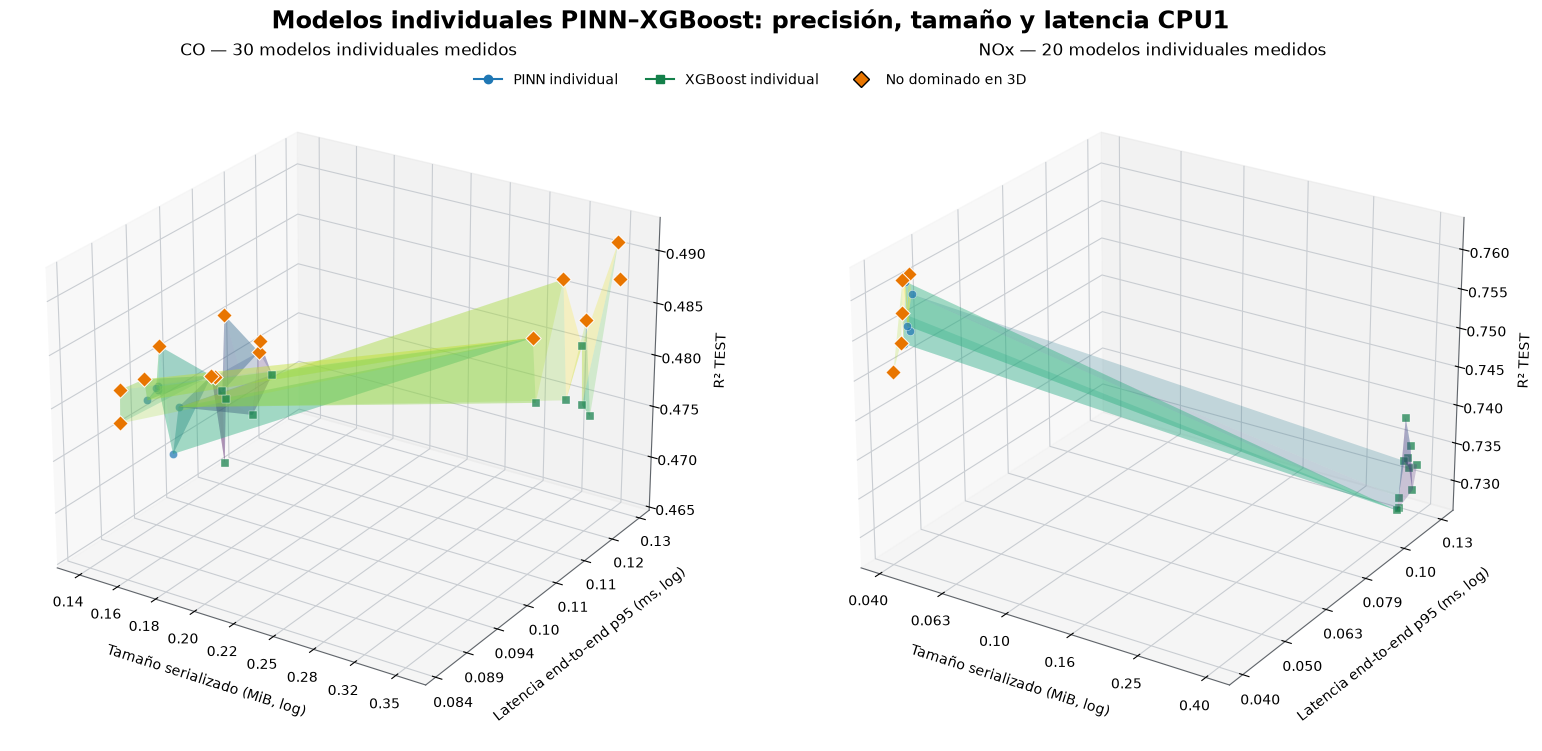

ART-01: C:\ChatGPT-Work\Walk_Forward R8\models\interp\work_pinn_xgboost_pareto_latency_r1\figures\01_superficie_3d_modelos_individuales.png


In [7]:
# [C-06.02] Superficie 3D con mediciones reales
figure = plt.figure(figsize=(16, 7.4), constrained_layout=True)
axes = {
    "CO": figure.add_subplot(1, 2, 1, projection="3d"),
    "NOx": figure.add_subplot(1, 2, 2, projection="3d"),
}

for pollutant, axis in axes.items():
    task_data = individual_models.loc[
        individual_models["pollutant"].eq(pollutant)
    ].copy()
    draw_measured_surface(axis, task_data)

    for family, style in FAMILY_STYLE.items():
        group = task_data.loc[task_data["family"].eq(family)]
        axis.scatter(
            np.log10(group["storage_mib"]),
            np.log10(group["latency_p95_ms"]),
            group["r2_test"],
            color=style["color"],
            marker=style["marker"],
            s=35,
            alpha=0.72,
            edgecolor="white",
            linewidth=0.35,
            depthshade=False,
        )

    frontier = task_data.loc[task_data["pareto_3d"]]
    axis.scatter(
        np.log10(frontier["storage_mib"]),
        np.log10(frontier["latency_p95_ms"]),
        frontier["r2_test"],
        color=PARETO_COLOR,
        marker="D",
        s=62,
        edgecolor="white",
        linewidth=0.7,
        depthshade=False,
        zorder=6,
    )
    axis.set_title(
        f"{pollutant} — {len(task_data)} modelos individuales medidos"
    )
    axis.set_xlabel("Tamaño serializado (MiB, log)", labelpad=9)
    axis.set_ylabel("Latencia end-to-end p95 (ms, log)", labelpad=11)
    axis.set_zlabel("R² TEST", labelpad=8)
    axis.xaxis.set_major_formatter(FuncFormatter(log_tick))
    axis.yaxis.set_major_formatter(FuncFormatter(log_tick))
    axis.view_init(elev=25, azim=-57)
    axis.grid(True)

figure.suptitle(
    "Modelos individuales PINN–XGBoost: precisión, tamaño y latencia CPU1",
    fontsize=17,
    fontweight="bold",
)
legend_handles = [
    Line2D(
        [0], [0], marker="o", color=FAMILY_STYLE["PINN"]["color"],
        markerfacecolor=FAMILY_STYLE["PINN"]["color"], label="PINN individual"
    ),
    Line2D(
        [0], [0], marker="s", color=FAMILY_STYLE["XGBoost"]["color"],
        markerfacecolor=FAMILY_STYLE["XGBoost"]["color"], label="XGBoost individual"
    ),
    Line2D(
        [0], [0], marker="D", color="none", markerfacecolor=PARETO_COLOR,
        markersize=8, label="No dominado en 3D"
    ),
]
figure.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.925),
    ncol=3,
    frameon=False,
)

figure_3d_path = FIGURES_DIR / "01_superficie_3d_modelos_individuales.png"
figure.savefig(figure_3d_path, dpi=240, bbox_inches="tight")
plt.show()
print(f"ART-01: {figure_3d_path}")

### FIG-02 — Proyecciones 2D de las fronteras

### C-06.03 — Precisión–almacenamiento y precisión–latencia

Los puntos pequeños son modelos por semilla. Los marcadores grandes son medianas por
familia/configuración. La línea discontinua une únicamente modelos globalmente no
dominados en cada proyección.

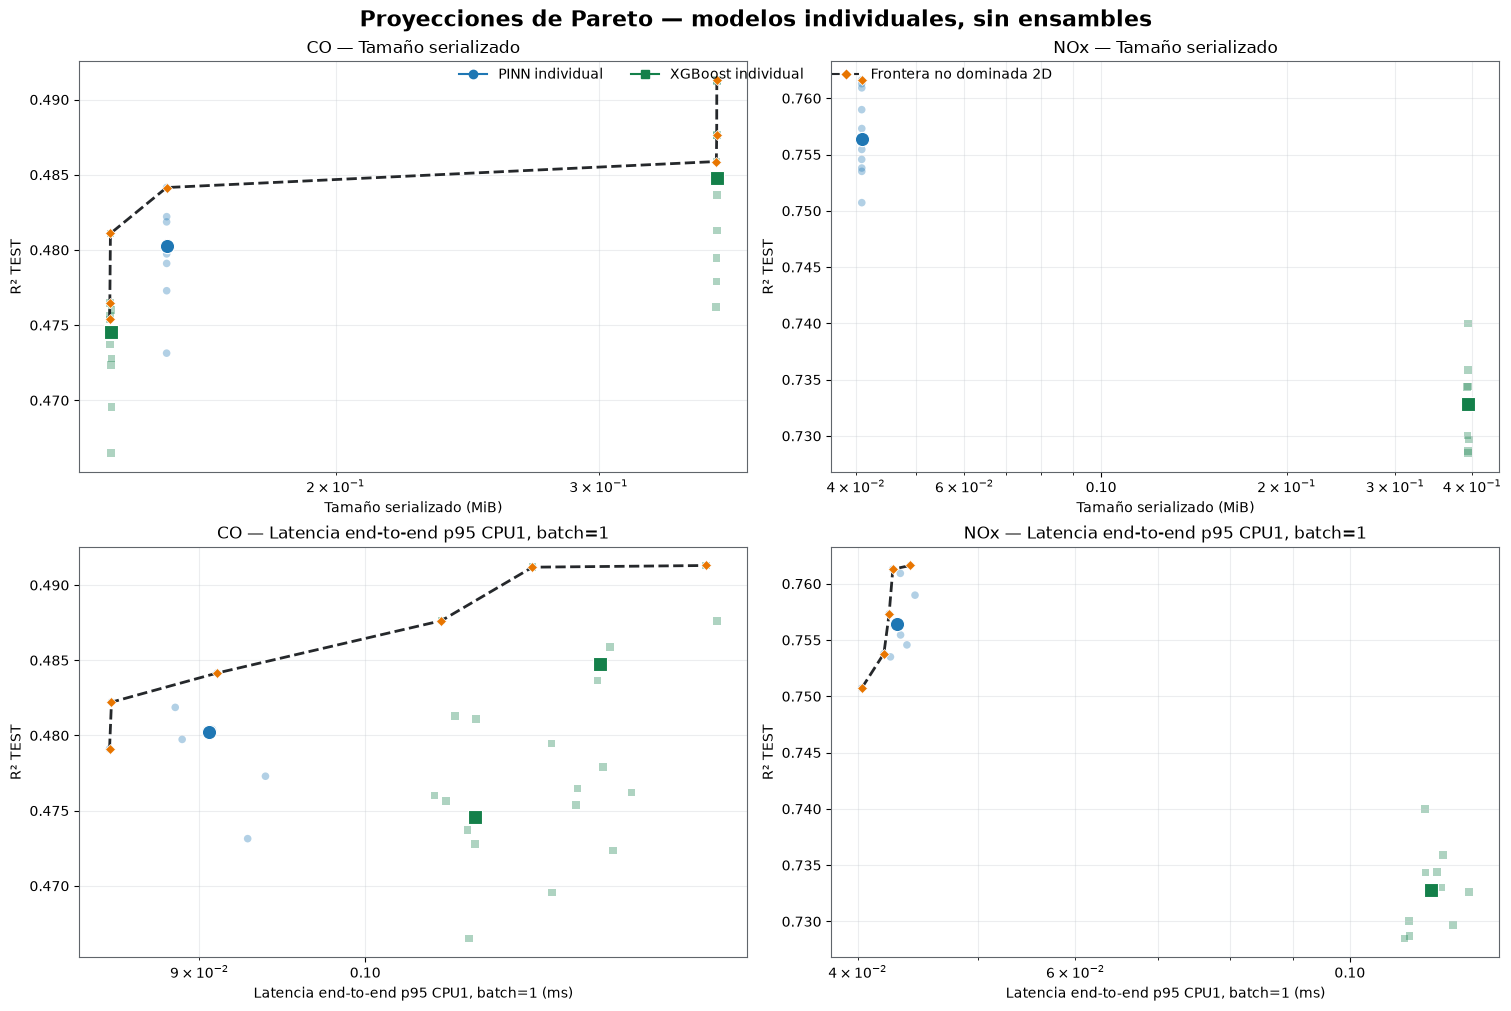

ART-02: C:\ChatGPT-Work\Walk_Forward R8\models\interp\work_pinn_xgboost_pareto_latency_r1\figures\02_proyecciones_pareto_2d.png


In [8]:
# [C-06.03] Proyecciones 2D de Pareto
figure, axes = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)

for column, pollutant in enumerate(("CO", "NOx")):
    task_data = individual_models.loc[
        individual_models["pollutant"].eq(pollutant)
    ].copy()

    for row, (x_column, x_label, flag_column) in enumerate(
        [
            ("storage_mib", "Tamaño serializado (MiB)", "pareto_size_r2"),
            (
                "latency_p95_ms",
                "Latencia end-to-end p95 CPU1, batch=1 (ms)",
                "pareto_latency_r2",
            ),
        ]
    ):
        axis = axes[row, column]
        for family, style in FAMILY_STYLE.items():
            group = task_data.loc[task_data["family"].eq(family)]
            axis.scatter(
                group[x_column],
                group["r2_test"],
                color=style["color"],
                marker=style["marker"],
                s=30,
                alpha=0.34,
                edgecolors="none",
            )
            medians = (
                group.groupby(["family", "config_hash"], as_index=False)
                .agg(
                    x_median=(x_column, "median"),
                    r2_median=("r2_test", "median"),
                )
            )
            axis.scatter(
                medians["x_median"],
                medians["r2_median"],
                color=style["color"],
                marker=style["marker"],
                s=105,
                edgecolor="white",
                linewidth=0.8,
                zorder=5,
            )

        frontier = task_data.loc[task_data[flag_column]].sort_values(x_column)
        axis.plot(
            frontier[x_column],
            frontier["r2_test"],
            color=NEUTRAL_COLOR,
            linestyle="--",
            linewidth=2.0,
            marker="D",
            markersize=5.5,
            markerfacecolor=PARETO_COLOR,
            markeredgecolor="white",
            markeredgewidth=0.5,
            zorder=6,
        )
        axis.set_xscale("log")
        formatter = ScalarFormatter()
        formatter.set_scientific(False)
        axis.xaxis.set_major_formatter(formatter)
        axis.set_title(f"{pollutant} — {x_label.split(' (')[0]}")
        axis.set_xlabel(x_label)
        axis.set_ylabel("R² TEST")
        axis.grid(True, which="both")

figure.suptitle(
    "Proyecciones de Pareto — modelos individuales, sin ensambles",
    fontsize=16,
    fontweight="bold",
)
projection_legend_handles = legend_handles[:2] + [
    Line2D(
        [0],
        [0],
        color=NEUTRAL_COLOR,
        linestyle="--",
        marker="D",
        markerfacecolor=PARETO_COLOR,
        markeredgecolor="white",
        label="Frontera no dominada 2D",
    )
]
figure.legend(
    handles=projection_legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.95),
    ncol=3,
    frameon=False,
)

figure_2d_path = FIGURES_DIR / "02_proyecciones_pareto_2d.png"
figure.savefig(figure_2d_path, dpi=240, bbox_inches="tight")
plt.show()
print(f"ART-02: {figure_2d_path}")

## SEC-07 — Persistencia y resumen

### C-07.01 — Tabla consolidada y resumen por configuración

**Artefactos:** CSV de modelos individuales, CSV agregado y reporte JSON de alcance.

In [9]:
# [C-07.01] Persistencia y resumen
models_path = TABLES_DIR / "modelos_individuales_precision_tamano_latencia.csv"
summary_path = TABLES_DIR / "resumen_por_configuracion.csv"
report_path = REPORTS_DIR / "methodology_scope.json"

individual_models.to_csv(models_path, index=False)

configuration_summary = (
    individual_models.groupby(
        ["pollutant", "family", "config_hash", "operating_point"],
        as_index=False,
    )
    .agg(
        model_count=("seed", "size"),
        r2_test_median=("r2_test", "median"),
        r2_test_min=("r2_test", "min"),
        storage_mib_median=("storage_mib", "median"),
        latency_p95_ms_median=("latency_p95_ms", "median"),
        latency_p95_ms_max=("latency_p95_ms", "max"),
        pareto_3d_count=("pareto_3d", "sum"),
    )
    .sort_values(["pollutant", "r2_test_median"], ascending=[True, False])
)
configuration_summary.to_csv(summary_path, index=False)

methodology_scope = {
    "status": "COMPLETE",
    "unit_of_analysis": "individual_seed_model",
    "ensembles_included": False,
    "accuracy": "R2 TEST per frozen seed model",
    "storage": "actual serialized checkpoint/package bytes",
    "latency": "end-to-end p95 CPU1 batch=1; median across five process restarts",
    "surface_role": "descriptive interpolation inside measured support only",
    "selection_role": "none; TEST is report-only",
    "model_counts": {
        f"{pollutant}_{family}": int(count)
        for (pollutant, family), count in individual_models.groupby(
            ["pollutant", "family"]
        ).size().items()
    },
}
report_path.write_text(
    json.dumps(methodology_scope, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

display(configuration_summary)
print(f"ART-03: {models_path}")
print(f"ART-04: {summary_path}")
print(f"ART-05: {report_path}")

,pollutant,family,config_hash,operating_point,model_count,r2_test_median,r2_test_min,storage_mib_median,latency_p95_ms_median,latency_p95_ms_max,pareto_3d_count
2,CO,XGBoost,ea194a7591c2d525684b104190b01d696f8700c39becc6...,OP10_ONE_ORDER,10,0.484772,0.476213,0.359791,0.116102,0.125035,5
0,CO,PINN,c63557b6e0aadf7878e5c25f58f0844be74f5f6048860d...,PINN_REFERENCE,10,0.480236,0.473138,0.154183,0.090557,0.093855,4
1,CO,XGBoost,a66dcfdafb3d7e9ebd699658f44e6a07a40674955ee5f8...,OP2_RELAXED_2X,10,0.474551,0.466490,0.141418,0.107255,0.117030,5
3,NOx,PINN,bddc29b599bbfe6a483d8c717eb8799def45c6c21f0167...,PINN_REFERENCE,10,0.756380,0.750724,0.040887,0.043005,0.044505,5
4,NOx,XGBoost,4472045906e22a100486fb574fd1735a24f8338bcef3a1...,OP10_ONE_ORDER,10,0.732796,0.728471,0.393419,0.116395,0.124840,0


ART-03: C:\ChatGPT-Work\Walk_Forward R8\models\interp\work_pinn_xgboost_pareto_latency_r1\tables\modelos_individuales_precision_tamano_latencia.csv
ART-04: C:\ChatGPT-Work\Walk_Forward R8\models\interp\work_pinn_xgboost_pareto_latency_r1\tables\resumen_por_configuracion.csv
ART-05: C:\ChatGPT-Work\Walk_Forward R8\models\interp\work_pinn_xgboost_pareto_latency_r1\reports\methodology_scope.json


## SEC-08 — Criterio de interpretación

- Cada punto corresponde a un modelo entrenado con una semilla; no se muestran ensambles.
- La latencia es end-to-end p95 CPU1, batch=1, bajo el contrato común R2.
- El tamaño corresponde al archivo desplegable real de cada modelo.
- La malla 3D facilita la lectura espacial, pero la conclusión se sustenta en los puntos
  medidos y en la dominancia de Pareto, no en valores interpolados.
- TEST se utiliza exclusivamente para reporte y no modifica la selección congelada.